In [15]:
from pathlib import Path
from PIL import Image

import pandas as pd
import random
import matplotlib.pyplot as plt
import shutil
import os
import json
import splitfolders

import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

In [16]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "testing":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATASET_TRAIN = PROJECT_DIR / "dataset" / "raw"  / "GCD" / "GCD" / "train" 
DATASET_TEST = PROJECT_DIR / "dataset" / "raw"  / "GCD" / "GCD" / "test" 

OUTPUT_DIR = PROJECT_DIR / "dataset" / "testing"

TRAIN_DIR = OUTPUT_DIR / "train"
# OUTPUT_DIR_ARG_TRAIN = OUTPUT_DIR / "train" / "arg"
VAL_DIR = OUTPUT_DIR / "val"

LOG_DIR = PROJECT_DIR / "logs" / "traning"

assert DATASET_TRAIN.exists(), (
    f"Folder TRAIN tidak ditemukan:\n{DATASET_TRAIN}\n"
    "Pastikan notebook dijalankan dari root cloud-classification."
)

assert DATASET_TEST.exists(), (
    f"Folder TEST tidak ditemukan:\n{DATASET_TRAIN}\n"
    "Pastikan notebook dijalankan dari root cloud-classification."
)

IMAGE_EXTENSIONS = {".jpg", ".jpeg"}

# Membuat pemilihan sampel dapat diulang.
TARGET_PER_CLASS = 3000
random.seed(42)

LOG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
VAL_DIR.mkdir(parents=True, exist_ok=True)



In [17]:
for class_folder in DATASET_TRAIN.iterdir():
    if class_folder.is_dir():
        class_name = class_folder.name

        # Buat subfolder kelas di dalam folder train dan val baru
        (TRAIN_DIR / class_name).mkdir(parents=True, exist_ok=True)
        (VAL_DIR / class_name).mkdir(parents=True, exist_ok=True)

        # Ambil semua file gambar di dalam kelas tersebut
        files = [f for f in class_folder.iterdir() if f.is_file() and f.suffix.lower() in ['.png', '.jpg', '.jpeg']]

        # Acak urutan file
        random.shuffle(files)

        # Hitung batas pemisahan (20% untuk Validation)
        val_count = int(len(files) * 0.2)
        val_files = files[:val_count]
        train_files = files[val_count:]

        print(f"Kelas [{class_name}]: Memisahkan {len(train_files)} ke Train Baru, {len(val_files)} ke Validation...")

        # Salin file ke folder Validation baru
        for file_path in val_files:
            shutil.copy(file_path, VAL_DIR / class_name / file_path.name)
            
        # Salin file ke folder Train baru
        for file_path in train_files:
            shutil.copy(file_path, TRAIN_DIR / class_name / file_path.name)

print(f"\nProses pemisahan sukses! Data Anda kini berada di: {OUTPUT_DIR}")

Kelas [1_cumulus]: Memisahkan 620 ke Train Baru, 155 ke Validation...
Kelas [2_altocumulus]: Memisahkan 580 ke Train Baru, 145 ke Validation...
Kelas [3_cirrus]: Memisahkan 923 ke Train Baru, 230 ke Validation...
Kelas [4_clearsky]: Memisahkan 1720 ke Train Baru, 430 ke Validation...
Kelas [5_stratocumulus]: Memisahkan 1477 ke Train Baru, 369 ke Validation...
Kelas [6_cumulonimbus]: Memisahkan 2403 ke Train Baru, 600 ke Validation...
Kelas [7_mixed]: Memisahkan 279 ke Train Baru, 69 ke Validation...

Proses pemisahan sukses! Data Anda kini berada di: d:\n8n-logsiswaparalayang\cloud-classification\dataset\testing


### Jumlah File Sebelum Argumentasi

In [18]:
direktori_train         = Path(TRAIN_DIR)
direktori_vallidation   = Path(VAL_DIR)
direktori_test          = Path(DATASET_TEST)

sebelum_file_dibagi     = Path(DATASET_TRAIN)

jumlah_file_before_split    = sum(len(files) for _, _, files in os.walk(sebelum_file_dibagi))
jumlah_file_train           = sum(len(files) for _, _, files in os.walk(direktori_train))
jumlah_file_val             = sum(len(files) for _, _, files in os.walk(direktori_vallidation))
jumlah_file_test            = sum(len(files) for _, _, files in os.walk(direktori_test))

TOTAL_FILE = jumlah_file_train+jumlah_file_val+jumlah_file_test

print(f"Total semua file (Train) sebelum dibagi     :   {jumlah_file_before_split}")
print(f"Total semua file (Test)                     :   {jumlah_file_test}")

print("----"*10)

print(f"Total semua file (Train 80%)            :   {jumlah_file_train}")
print(f"Total semua file (Val 20%)              :   {jumlah_file_val}")
print(f"Total semua file (Test)                 :   {jumlah_file_test}")

print("----"*10)
print(f"Total semua file : {TOTAL_FILE}")

# 1. Siapkan list kosong untuk menampung data
data_folder = []

# 2. Kelas Awan | amsumsi bahwa data pada kedua subfolder memiliki penamaan yang sama 
kelas_list = [e.name for e in os.scandir(direktori_train) if e.is_dir()]

# 3. Iterasi setiap nama subfolder untuk menghitung isi di kedua folder utama

for nama in kelas_list:
    folder_awal     = os.path.join(sebelum_file_dibagi,nama)
    folder_train    = os.path.join(direktori_train,nama)
    folder_val      = os.path.join(direktori_vallidation,nama)
    folder_test     = os.path.join(direktori_test,nama)

    # Hitung jumlah file di Folder awal 
    if os.path.exists(folder_awal):
        file_awal = sum(1 for e in os.scandir(folder_awal) if e.is_file())
    else:
        file_awal = 0

    # Hitung jumlah file di Folder train 
    if os.path.exists(folder_train):
        file_train = sum(1 for e in os.scandir(folder_train) if e.is_file())
    else:
        file_train = 0

    # Hitung jumlah file di Folder val
    if os.path.exists(folder_val):
        file_val = sum(1 for e in os.scandir(folder_val) if e.is_file())
    else:
        file_val = 0

    # Hitung jumlah file di Folder test
    if os.path.exists(folder_test):
        file_test = sum(1 for e in os.scandir(folder_test) if e.is_file())
    else:
        file_test = 0

    # Masukkan ke dalam list data
    data_folder.append({
        "Nama Subfolder": nama,
        "Jumlah File Sebelum (Train) Dibagi" : file_awal,
        "Jumlah File (Train)" : file_train,
        "Jumlah File (VAL)" : file_val,
        "Jumlah File (Test)"  : file_test,
        "Total file per kelas" : file_train+file_test+file_val
    })

# 3. Ubah menjadi DataFrame
df_jumlah_file = pd.DataFrame(data_folder)    

# 4. Tampilkan DataFrame
print(df_jumlah_file)

Total semua file (Train) sebelum dibagi     :   10000
Total semua file (Test)                     :   9000
----------------------------------------
Total semua file (Train 80%)            :   8002
Total semua file (Val 20%)              :   1998
Total semua file (Test)                 :   9000
----------------------------------------
Total semua file : 19000
    Nama Subfolder  Jumlah File Sebelum (Train) Dibagi  Jumlah File (Train)  \
0        1_cumulus                                 775                  620   
1    2_altocumulus                                 725                  580   
2         3_cirrus                                1153                  923   
3       4_clearsky                                2150                 1720   
4  5_stratocumulus                                1846                 1477   
5   6_cumulonimbus                                3003                 2403   
6          7_mixed                                 348                  279   

   Jum

Dataset Train di bagi menjadi 80:20 
- Train 80% | dan akan dilakukan untuk Argumentasi agar seimbang setiap kelas mecapai 300 sampel per kelas
- Val 20% 

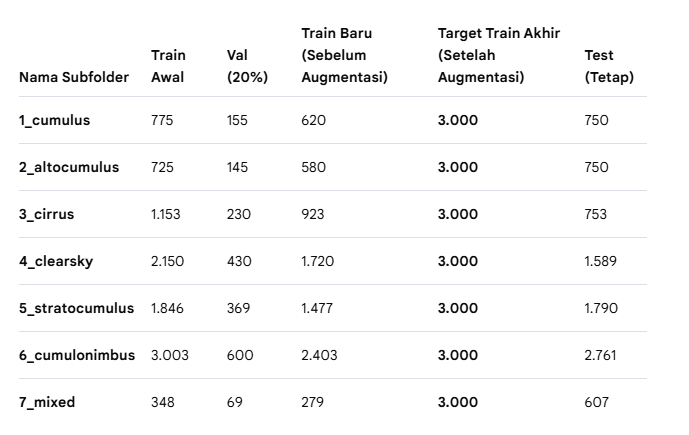

In [19]:
log_summary = {
    
    "total_file_train": jumlah_file_train,
    "total_file_val": jumlah_file_val,
    "total_file_test": jumlah_file_test,
    "total_keseluruhan": jumlah_file_train+jumlah_file_test+jumlah_file_val
}

json_log_data = {
    "summary": log_summary,
    "file_per_subfolder": data_folder
}


with open(LOG_DIR / "log_dataset.json", "w", encoding="utf-8") as json_file:
    json.dump(json_log_data, json_file, indent=4, ensure_ascii=False)
print("Berhasil menyimpan log ke 'log_dataset.json'")


df_jumlah_file.to_csv(LOG_DIR / "tabel_jumlah_dataset_citra_awan.csv",index=False)
print("Berhasil menyimpan tabel ke 'tabel_jumlah_dataset_citra_awan.csv'")

Berhasil menyimpan log ke 'log_dataset.json'
Berhasil menyimpan tabel ke 'tabel_jumlah_dataset_citra_awan.csv'


In [ ]:
# Mencegah duplikasi ketika kode dijalankan ulang.
# if any(Test.iterdir()):
#     raise RuntimeError(
#         f"Folder output tidak kosong:\n{OUTPUT_DIR_ARG_TRAIN}\n"
#         "Gunakan folder output baru atau kosongkan secara manual."
#     )

In [20]:
# ============================================================
# 2. MENGAMBIL SATU CITRA DARI SETIAP KELAS
# ============================================================

sample_images = {}

# Membaca seluruh folder kelas di dalam folder train.
class_directories = sorted(
    directory
    for directory in TRAIN_DIR.iterdir()
    if directory.is_dir()
)

for class_directory in class_directories:

    # Mencari seluruh citra pada folder kelas.
    image_paths = [
        path
        for path in class_directory.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Melewati kelas apabila tidak memiliki citra.
    if not image_paths:
        print(f"Tidak ada citra pada kelas: {class_directory.name}")
        continue

    # Memilih satu citra secara acak.
    selected_image = random.choice(image_paths)

    # Menyimpan nama kelas dan lokasi citra.
    sample_images[class_directory.name] = selected_image


print(f"Jumlah kelas ditemukan: {len(sample_images)}")

for class_name, image_path in sample_images.items():
    print(f"{class_name:<20} -> {image_path.name}")

Jumlah kelas ditemukan: 7
1_cumulus            -> 1_cumulus_000007.jpg
2_altocumulus        -> 2_altocumulus_000011.jpg
3_cirrus             -> 3_cirrus_000859.jpg
4_clearsky           -> 4_clearsky_000451.jpg
5_stratocumulus      -> 5_stratocumulus_001070.jpg
6_cumulonimbus       -> 6_cumulonimbus_002846.jpg
7_mixed              -> 7_mixed_000309.jpg


## Argumrntasi 
### Geometric Transformation

 a) Original 

 b) Translasi Siklik (Cyclic Translation)

 c) flipping

 d) rotation

 ### Color Transformation 

 e) color enhancement

 f) contrast enhancement

 g) brightness enhancement

In [21]:
# Semua citra diseragamkan menjadi 224 × 224 piksel.
prepare_image = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])

# Define augmentations by category
augmentations = {
    # a) Citra asli tanpa transformasi.
    "a)" : T.Lambda(
        lambda x: x.clone()
    ),

    # b) Menggeser citra 100 piksel ke bawah
    #    dan 250 piksel ke kanan secara siklik.
    "b)": T.Lambda(
        lambda x: torch.roll(
            x,
            shifts=(100, 250),
            dims=(-2, -1)
        )
    ),

    # c) Membalik citra secara horizontal.
    "c)": T.RandomHorizontalFlip(
        p=1.0
    ),

    # d) Memutar citra sebesar 15 derajat.
    "d)": T.Lambda(
        lambda x: TF.rotate(
            x,
            angle=15,
            interpolation=InterpolationMode.BILINEAR,
            fill=0
        )
    ),

    # e) Meningkatkan saturasi warna sebesar 50%.
    "e)": T.Lambda(
        lambda x: TF.adjust_saturation(
            x,
            saturation_factor=1.5
        )
    ),

    # f) Meningkatkan kontras sebesar 50%.
    "f)": T.Lambda(
        lambda x: TF.adjust_contrast(
            x,
            contrast_factor=1.5
        )
    ),

    # g) Meningkatkan kecerahan sebesar 50%.
    "g)": T.Lambda(
        lambda x: TF.adjust_brightness(
            x,
            brightness_factor=1.5
        )
    ),
}

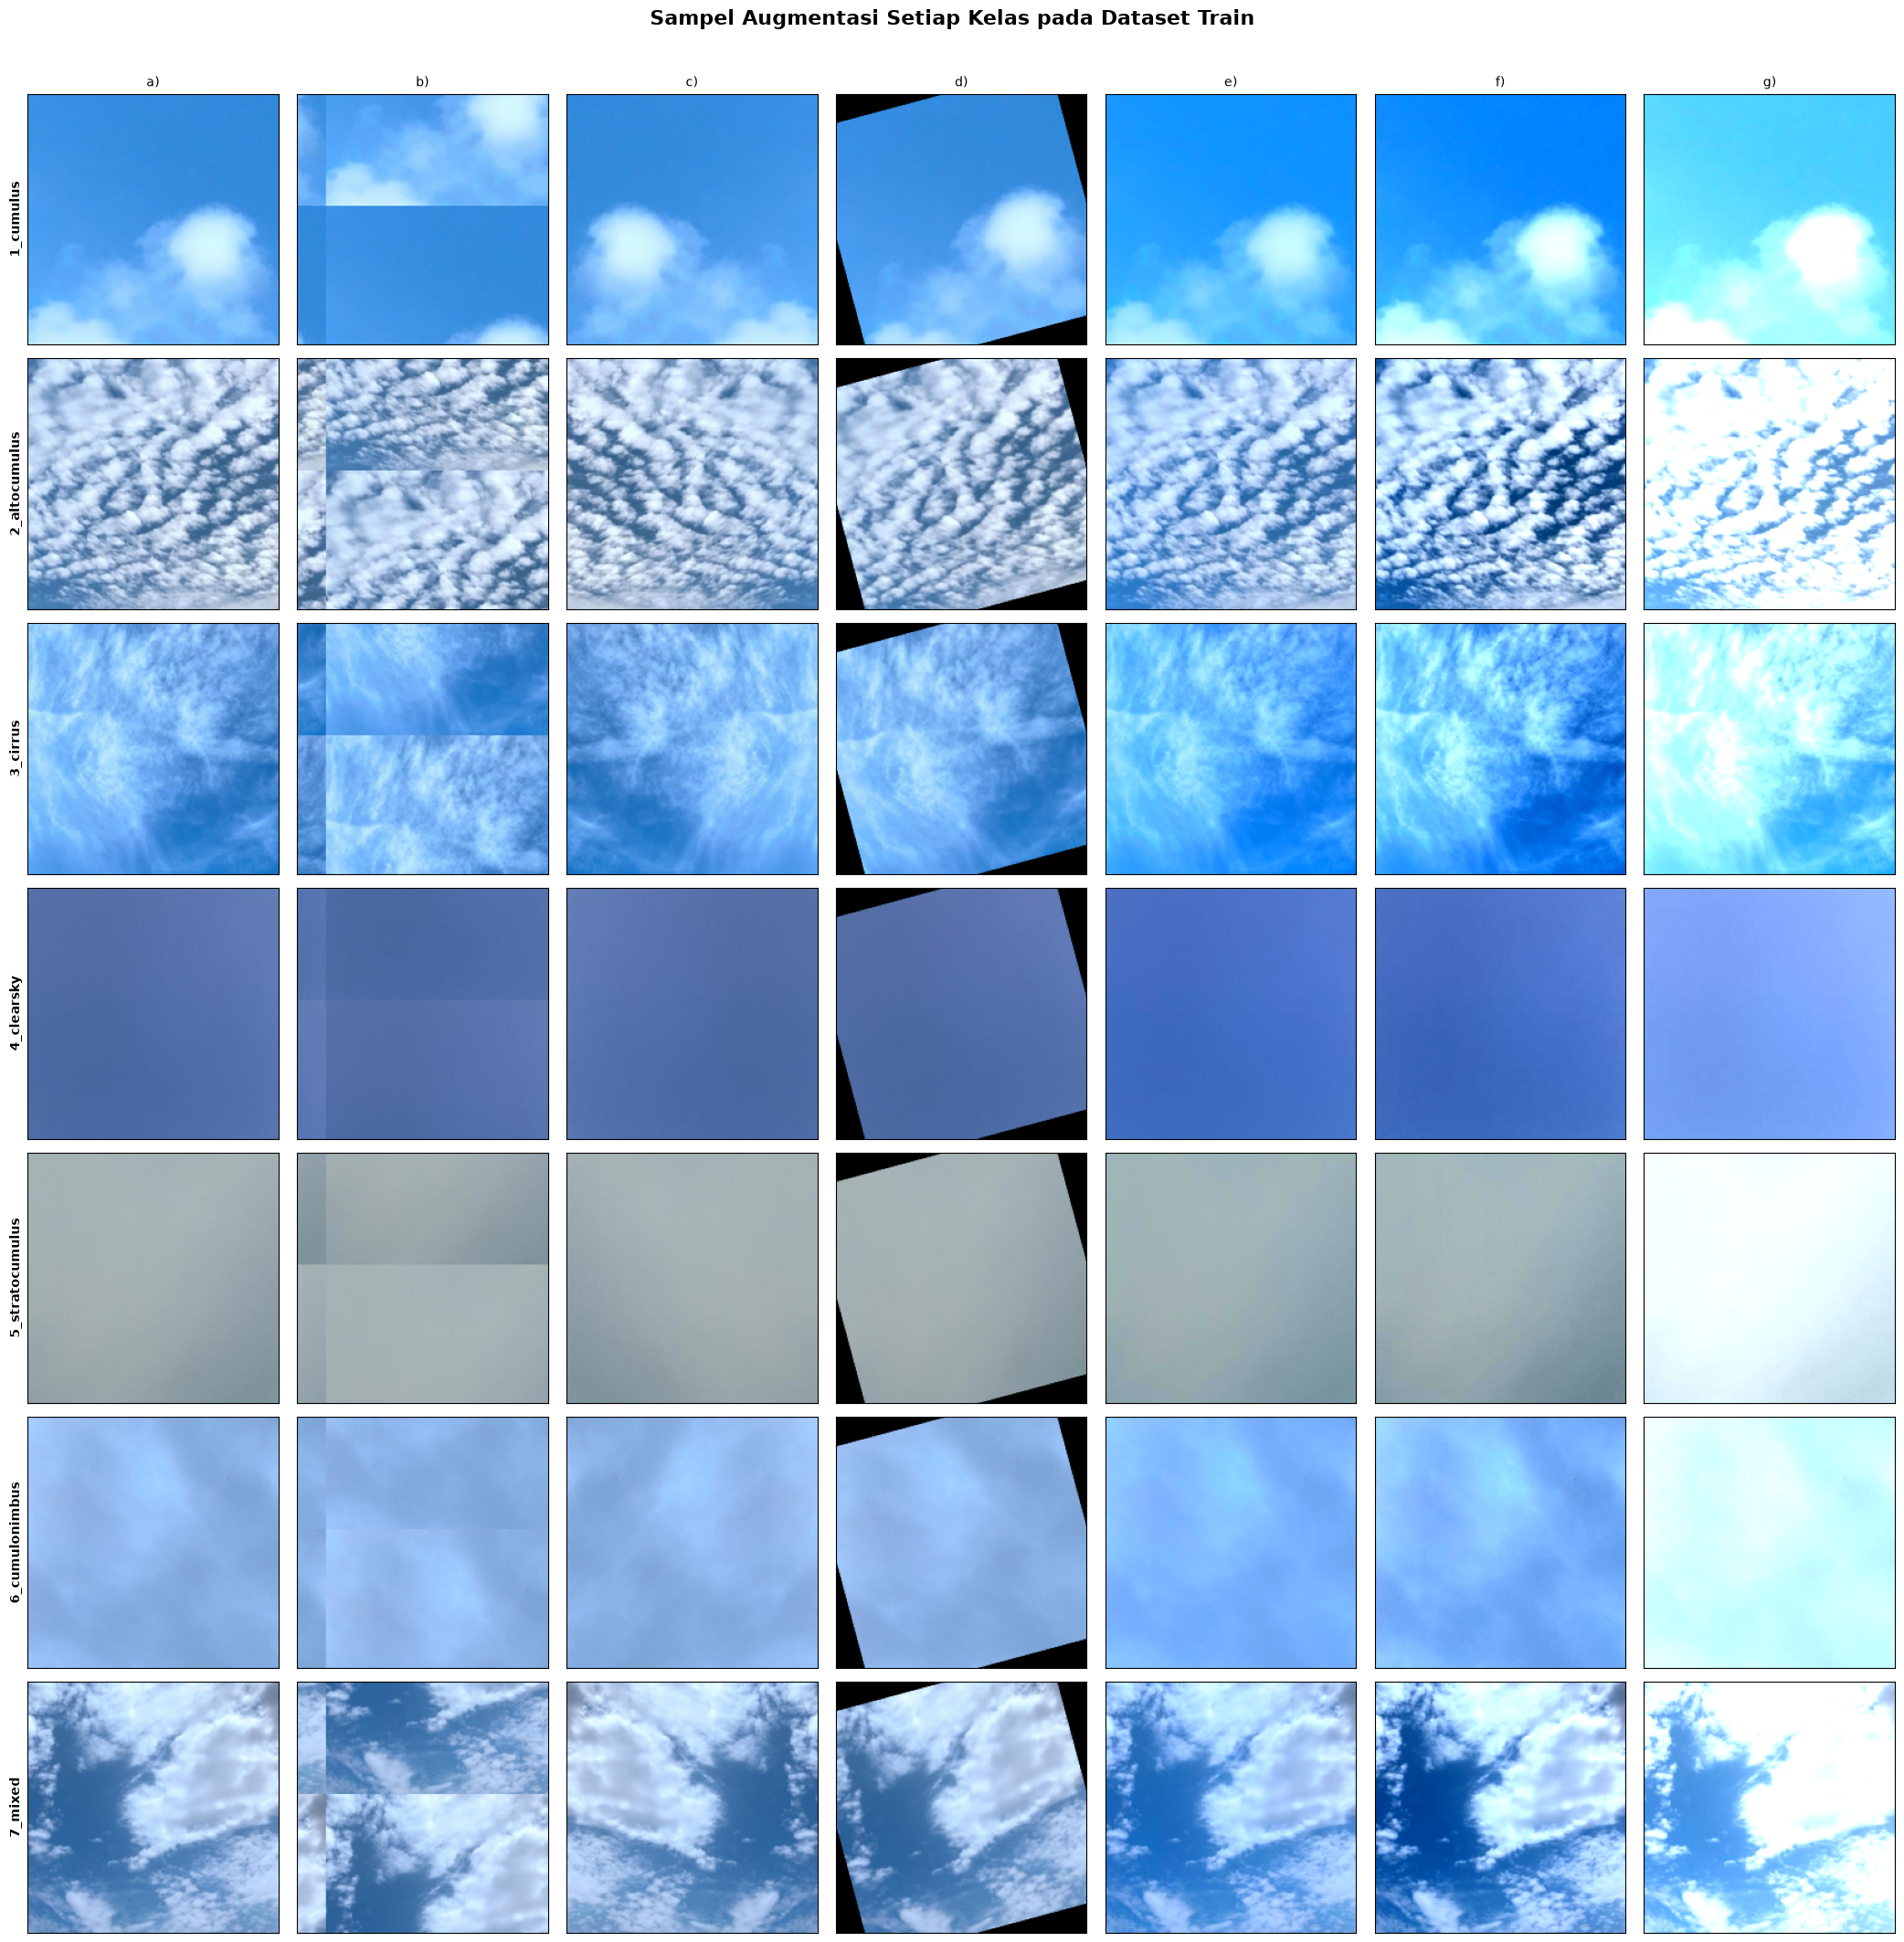

In [22]:
number_of_classes = len(sample_images)
number_of_transformations = len(augmentations)

fig, axes = plt.subplots(
    nrows=number_of_classes,
    ncols=number_of_transformations,
    figsize=(21, 3 * number_of_classes)
)

# Menangani kondisi jika hanya ada satu kelas.
if number_of_classes == 1:
    axes = axes.reshape(1, -1)


for row_index, (class_name, image_path) in enumerate(
    sample_images.items()
):
    # Membaca citra dalam format RGB.
    original_image = Image.open(image_path).convert("RGB")

    # Mengubah citra menjadi tensor berukuran 224 × 224.
    image_tensor = prepare_image(original_image)

    for column_index, (title, transformation) in enumerate(
        augmentations.items()
    ):
        # Menerapkan transformasi.
        transformed_image = transformation(image_tensor)

        # Mengubah format C × H × W menjadi H × W × C.
        display_image = transformed_image.permute(1, 2, 0)

        # Memastikan nilai piksel berada pada rentang 0–1.
        display_image = display_image.clamp(0, 1)

        # Menampilkan citra.
        axes[row_index, column_index].imshow(
            display_image.cpu().numpy()
        )

        # Menampilkan nama transformasi pada baris pertama.
        if row_index == 0:
            axes[row_index, column_index].set_title(
                title,
                fontsize=10
            )

        # Menampilkan nama kelas pada kolom pertama.
        if column_index == 0:
            axes[row_index, column_index].set_ylabel(
                class_name,
                fontsize=10,
                fontweight="bold"
            )

        axes[row_index, column_index].set_xticks([])
        axes[row_index, column_index].set_yticks([])


plt.suptitle(
    "Sampel Augmentasi Setiap Kelas pada Dataset Train",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

nama_sampel_augmentasi = LOG_DIR / "Sampel Augmentasi.png"

plt.savefig(nama_sampel_augmentasi, dpi=150, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# 2. MENGHITUNG JUMLAH GAMBAR PER KELAS
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
}

class_counts = []

# Membaca setiap folder kelas.
for class_directory in sorted(TRAIN_DIR.iterdir()):

    # Hanya memproses folder.
    if not class_directory.is_dir():
        continue

    # Mengambil seluruh file gambar di dalam kelas.
    image_paths = [
        path
        for path in class_directory.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Menyimpan nama kelas dan jumlah gambar.
    class_counts.append({
        "Nama Kelas": class_directory.name,
        "Jumlah Gambar (Train)": len(image_paths),
    })


# ============================================================
# 3. MENAMPILKAN HASIL
# ============================================================

class_counts_df = pd.DataFrame(class_counts)

display(class_counts_df)

print("=" * 50)
print(f"Jumlah kelas       : {len(class_counts_df)}")
print(f"Total gambar train : {class_counts_df['Jumlah Gambar (Train)'].sum()}")

,Nama Kelas,Jumlah Gambar (Train)
0,1_cumulus,620
1,2_altocumulus,580
2,3_cirrus,923
3,4_clearsky,1720
4,5_stratocumulus,1477
5,6_cumulonimbus,2403
6,7_mixed,279


Jumlah kelas       : 7
Total gambar train : 8002


In [24]:
# Transformasi yang digunakan untuk membuat citra tambahan.
# Transformasi a) tidak digunakan karena merupakan citra asli.
augmentation_labels = [
    "b)",
    "c)",
    "d)",
    "e)",
    "f)",
    "g)",
]

# Mengubah tensor kembali menjadi citra PIL agar dapat disimpan.
to_pil_image = T.ToPILImage()

In [25]:
balancing_summary = [] 
class_directories = sorted(
    directory
    for directory in TRAIN_DIR.iterdir()
    if directory.is_dir()
)

for class_directory in class_directories:
    class_name = class_directory.name
    output_class_directory = TRAIN_DIR / class_name
    output_class_directory.mkdir(parents=True, exist_ok=True)

    # Mengambil seluruh gambar dalam kelas.
    image_paths = sorted([
        path
        for path in class_directory.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    ])

    initial_count = len(image_paths)

    if initial_count == 0:
        print(f"Kelas {class_name} tidak memiliki gambar.")
        continue

    # --------------------------------------------------------
    # DOWNSAMPLING
    # Kelas dengan lebih dari 3.000 gambar dipilih sebanyak
    # 3.000 gambar secara acak.
    # --------------------------------------------------------

    if initial_count >= TARGET_PER_CLASS:
        selected_images = random.sample(
            image_paths,
            TARGET_PER_CLASS
        )

        augmentation_count = 0
        removed_count = initial_count - TARGET_PER_CLASS

    # --------------------------------------------------------
    # OVERSAMPLING
    # Seluruh gambar asli dipertahankan, kemudian ditambah
    # gambar hasil augmentasi hingga mencapai 3.000 gambar.
    # --------------------------------------------------------

    else:
        selected_images = image_paths

        augmentation_count = (
            TARGET_PER_CLASS - initial_count
        )

        removed_count = 0

    # # Menyalin gambar asli yang terpilih.
    # for index, source_path in enumerate(
    #     selected_images,
    #     start=1
    # ):
    #     destination_path = (
    #         output_class_directory
    #         / f"original_{index:04d}{source_path.suffix.lower()}"
    #     )

    #     shutil.copy2(
    #         source_path,
    #         destination_path
    #     )

        # Membuat gambar hasil augmentasi.
    for augmentation_index in range(
        1,
        augmentation_count + 1
    ):
        # Memilih gambar sumber dengan pengembalian.
        source_path = random.choice(image_paths)

        # Membuka gambar sumber.
        with Image.open(source_path) as image:

            # Mengubah citra menjadi RGB.
            image = image.convert("RGB")

            # Menyeragamkan ukuran dan mengubah citra menjadi tensor.
            image_tensor = prepare_image(image)

            # Memilih transformasi secara bergiliran dari b) sampai g).
            augmentation_label = augmentation_labels[
                (augmentation_index - 1) % len(augmentation_labels)
            ]

            # Mengambil fungsi transformasi dari dictionary.
            selected_transformation = augmentations[
                augmentation_label
            ]

            # Menerapkan transformasi pada tensor citra.
            augmented_tensor = selected_transformation(
                image_tensor
            )

            # Memastikan nilai piksel berada pada rentang 0–1.
            augmented_tensor = augmented_tensor.clamp(0, 1)

            # Mengubah tensor hasil augmentasi menjadi citra PIL.
            augmented_image = to_pil_image(
                augmented_tensor
            )

        # Menentukan nama hasil augmentasi.
        output_path = (
            output_class_directory
            / f"augmented_{augmentation_index:04d}.jpg"
        )

        # Menyimpan hasil augmentasi.
        augmented_image.save(
            output_path,
            format="JPEG",
            quality=95
        )

    balancing_summary.append({
        "Nama Kelas": class_name,
        "Jumlah Awal": initial_count,
        "Augmentasi": augmentation_count,
        "Dikurangi": removed_count,
        "Jumlah Akhir": TARGET_PER_CLASS,
    })

    print(
        f"{class_name:<20} | "
        f"awal={initial_count:4d} | "
        f"augmentasi={augmentation_count:4d} | "
        f"dihapus={removed_count:2d} | "
        f"akhir={TARGET_PER_CLASS:4d}"
    )



1_cumulus            | awal= 620 | augmentasi=2380 | dihapus= 0 | akhir=3000
2_altocumulus        | awal= 580 | augmentasi=2420 | dihapus= 0 | akhir=3000
3_cirrus             | awal= 923 | augmentasi=2077 | dihapus= 0 | akhir=3000
4_clearsky           | awal=1720 | augmentasi=1280 | dihapus= 0 | akhir=3000
5_stratocumulus      | awal=1477 | augmentasi=1523 | dihapus= 0 | akhir=3000
6_cumulonimbus       | awal=2403 | augmentasi= 597 | dihapus= 0 | akhir=3000
7_mixed              | awal= 279 | augmentasi=2721 | dihapus= 0 | akhir=3000


In [26]:
#============================================================
# VERIFIKASI HASIL PENYEIMBANGAN DATASET
# ============================================================

summary_df = pd.DataFrame(balancing_summary)

# Memastikan ringkasan tidak kosong.
assert not summary_df.empty, (
    "Ringkasan penyeimbangan kosong. "
    "Jalankan proses penyeimbangan terlebih dahulu."
)

# Menampilkan ringkasan proses penyeimbangan.
display(summary_df)


# Menghitung target total secara dinamis.
number_of_classes = len(summary_df)

expected_total = (
    number_of_classes * TARGET_PER_CLASS
)

summary_total = (
    summary_df["Jumlah Akhir"].sum()
)


# Menghitung file gambar yang benar-benar tersimpan.
actual_counts = []

for class_directory in sorted(TRAIN_DIR.iterdir()):

    # Hanya memeriksa folder kelas.
    if not class_directory.is_dir():
        continue

    # Mengambil seluruh gambar pada folder kelas.
    image_paths = [
        path
        for path in class_directory.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    actual_counts.append({
        "Nama Kelas": class_directory.name,
        "Jumlah Aktual": len(image_paths),
    })


# Membuat tabel jumlah aktual.
actual_counts_df = pd.DataFrame(actual_counts)

# Menghitung total gambar aktual.
actual_total = (
    actual_counts_df["Jumlah Aktual"].sum()
)


# Menampilkan hasil pemeriksaan.
display(actual_counts_df)

print("=" * 60)
print(f"Jumlah kelas             : {number_of_classes}")
print(f"Target setiap kelas      : {TARGET_PER_CLASS}")
print(f"Total berdasarkan catatan: {summary_total}")
print(f"Total yang diharapkan    : {expected_total}")
print(f"Total file aktual        : {actual_total}")
print("=" * 60)


# Memastikan catatan akhir setiap kelas sudah sesuai target.
assert (
    summary_df["Jumlah Akhir"] == TARGET_PER_CLASS
).all(), (
    "Ringkasan menunjukkan masih ada kelas "
    "yang belum mencapai target."
)


# Memastikan setiap folder kelas benar-benar memiliki 3.000 gambar.
assert (
    actual_counts_df["Jumlah Aktual"] == TARGET_PER_CLASS
).all(), (
    "Masih terdapat folder kelas yang jumlah "
    "gambar aktualnya belum mencapai target."
)


# Memastikan total berdasarkan ringkasan sesuai target.
assert summary_total == expected_total, (
    f"Total pada ringkasan seharusnya {expected_total:,}, "
    f"tetapi ditemukan {summary_total:,}."
)


# Memastikan total file aktual sesuai target.
assert actual_total == expected_total, (
    f"Total file aktual seharusnya {expected_total:,}, "
    f"tetapi ditemukan {actual_total:,}."
)


print(
    "Verifikasi berhasil: setiap kelas berisi "
    f"{TARGET_PER_CLASS:,} gambar."
)

print(
    f"Total dataset akhir: {actual_total:,} gambar."
)

,Nama Kelas,Jumlah Awal,Augmentasi,Dikurangi,Jumlah Akhir
0,1_cumulus,620,2380,0,3000
1,2_altocumulus,580,2420,0,3000
2,3_cirrus,923,2077,0,3000
3,4_clearsky,1720,1280,0,3000
4,5_stratocumulus,1477,1523,0,3000
5,6_cumulonimbus,2403,597,0,3000
6,7_mixed,279,2721,0,3000


,Nama Kelas,Jumlah Aktual
0,1_cumulus,3000
1,2_altocumulus,3000
2,3_cirrus,3000
3,4_clearsky,3000
4,5_stratocumulus,3000
5,6_cumulonimbus,3000
6,7_mixed,3000


Jumlah kelas             : 7
Target setiap kelas      : 3000
Total berdasarkan catatan: 21000
Total yang diharapkan    : 21000
Total file aktual        : 21000
Verifikasi berhasil: setiap kelas berisi 3,000 gambar.
Total dataset akhir: 21,000 gambar.


In [ ]:

# 1. Ambil DataFrame pertama (asumsi nama variabelnya: df_detail)
# Kita ubah DataFrame detail menjadi dictionary dengan 'Nama Kelas' sebagai Key utamanya
detail_dict = {}
for _, row in summary_df.iterrows():
    kelas = row['Nama Kelas']
    detail_dict[kelas] = {
        "jumlah_awal": int(row['Jumlah Awal']),
        "augmentasi": int(row['Augmentasi']),
        "dikurangi": int(row['Dikurangi']),
        "jumlah_akhir": int(row['Jumlah Akhir'])
    }

# 2. Konversi nilai total dataset akhir ke tipe int murni Python
clean_total = int(actual_total)

# 3. Susun struktur log JSON yang komprehensif
json_log_data_arg = {
    "total_dataset_akhir": clean_total,
    "rincian_per_kelas": detail_dict
}

In [44]:
with open(LOG_DIR / "log_dataset_argumentasi.json", "w", encoding="utf-8") as json_file:
    json.dump(json_log_data_arg, json_file, indent=4, ensure_ascii=False)
print("Berhasil menyimpan log ke 'log_dataset_argumentasi.json'")

summary_df.to_csv(LOG_DIR / "tabel_jumlah_dataset_argumentasi_citra_awan.csv",index=False)
print("Berhasil menyimpan tabel ke 'tabel_jumlah_dataset_argumentasi_citra_awan.csv'")

Berhasil menyimpan log ke 'log_dataset_argumentasi.json'
Berhasil menyimpan tabel ke 'tabel_jumlah_dataset_argumentasi_citra_awan.csv'
